# 2.9 Filtrer les données

#### Introduction
Le filtrage est une technique essentielle de l'analyse des séries temporelles, en particulier en géosciences, où les signaux sont souvent contaminés par du bruit ou contiennent à la fois des composantes de courte et de longue durée. Les filtres aident à isoler l'information utile des données brutes en atténuant les fréquences indésirables ou en rehaussant certaines caractéristiques. Dans cette leçon, nous filtrerons des séries temporelles, avec un accent sur une variable climatique présentant une saisonnalité et une tendance positive. Les données climatiques présentent souvent à la fois des variations de court terme (comme les cycles journaliers ou saisonniers) et des tendances de long terme (comme le réchauffement océanique). En appliquant des filtres, nous pouvons nous concentrer sur des composantes précises d'un signal climatique, que l'on s'intéresse aux tendances climatiques de long terme ou aux régimes météorologiques de court terme.

#### Pourquoi le filtrage est important
- **Réduction du bruit** : les données géophysiques contiennent souvent du bruit issu des instruments de mesure, des conditions environnementales ou de signaux sans rapport. Le filtrage aide à retirer ce bruit et rehausse le signal d'intérêt.
- **Isolation de caractéristiques** : en se concentrant sur des bandes de fréquences précises, le filtrage permet d'isoler des phénomènes de court terme (comme les tempêtes) ou des processus de long terme (comme les tendances climatiques).
- **Lissage des données** : en géosciences, lisser des séries temporelles bruitées rend les motifs plus apparents et améliore la clarté des visualisations.
- **Détection de tendances** : le filtrage de long terme peut révéler des tendances sous-jacentes dans les données, ce qui compte pour les études du changement climatique, de la circulation océanique et du réchauffement global.

#### Types de filtres
- **Filtre passe-bas** : laisse passer les composantes de basse fréquence en atténuant les composantes de haute fréquence. Utile pour isoler les tendances de long terme.
- **Filtre passe-haut** : laisse passer les composantes de haute fréquence en atténuant les composantes de basse fréquence. Utile pour se concentrer sur les fluctuations de court terme.
- **Filtre passe-bande** : laisse passer une plage de fréquences donnée en bloquant les fréquences plus hautes et plus basses. Utile pour analyser des phénomènes dans une gamme de fréquences particulière.
- **Filtres de lissage** : comme les moyennes glissantes ou les filtres gaussiens, ils lissent les données pour retirer les fluctuations de court terme.

Les données peuvent superposer plusieurs signaux de fréquences diverses. Pour retirer ou extraire des signaux précis qui ne se recouvrent pas en fréquence, nous pouvons *filtrer* les données.

Le filtre peut être :
* **passe-haut** : réduit les signaux aux fréquences *inférieures* à une fréquence de coupure $f_c$, ne laisse passer que les signaux *au-dessus* de $f_c$. Souvent paramétré dans les fonctions comme ``hp`` ou ``highpass``.
* **passe-bas** : réduit les signaux aux fréquences *supérieures* à une fréquence de coupure $f_c$, ne laisse passer que les signaux *en dessous* de ce $f_c$. Souvent paramétré comme ``lp`` ou ``lowpass``.
* **passe-bande** : réduit les signaux aux fréquences *inférieures* à une fréquence de coupure basse $f_{c1}$ et aux fréquences *supérieures* à une fréquence de coupure haute $f_{c2}>f_{c1}$. Souvent paramétré comme ``bp`` ou ``bandpass``.

Il existe différents types de filtres. Les plus courants sont ``butterworth`` et ``chebyshev``, mais il en existe d'autres.

![Filters](../img/filters.png)

**Figure** : exemples de filtres illustrés [ici](https://www.ni.com/docs/en-US/bundle/labview/page/lvanlsconcepts/lvac_iir_filter_types.html).


## Exemple 1 : filtrer une série temporelle climatique synthétique

Nous construisons une série climatique journalière synthétique à trois composantes connues : une tendance linéaire de réchauffement, un cycle saisonnier et du bruit. Comme nous la construisons nous-mêmes, nous connaissons exactement les vraies composantes, et nous pouvons donc vérifier dans quelle mesure le filtrage retrouve chacune.

Nous rendons le bruit **coloré** (rouge) plutôt que blanc : le vrai bruit climatique a plus de puissance aux basses fréquences qu'aux hautes fréquences. Nous le générons en façonnant le spectre d'un bruit blanc dans le domaine de Fourier — mettre le spectre d'amplitude à l'échelle en $1/f$, garder des phases aléatoires et appliquer la transformée inverse. Ce choix rend l'exercice honnête : le bruit rouge a de la puissance à *toutes* les fréquences, y compris les basses fréquences où vivent la tendance et le cycle saisonnier, donc aucun filtre ne peut séparer parfaitement les composantes.

🖥️ [**Diapositives du cours — Séance 08 (ven. 16 oct.)**](https://geo-smart.github.io/mlgeo-book/slides/2026/lec08_repairing_records.html)

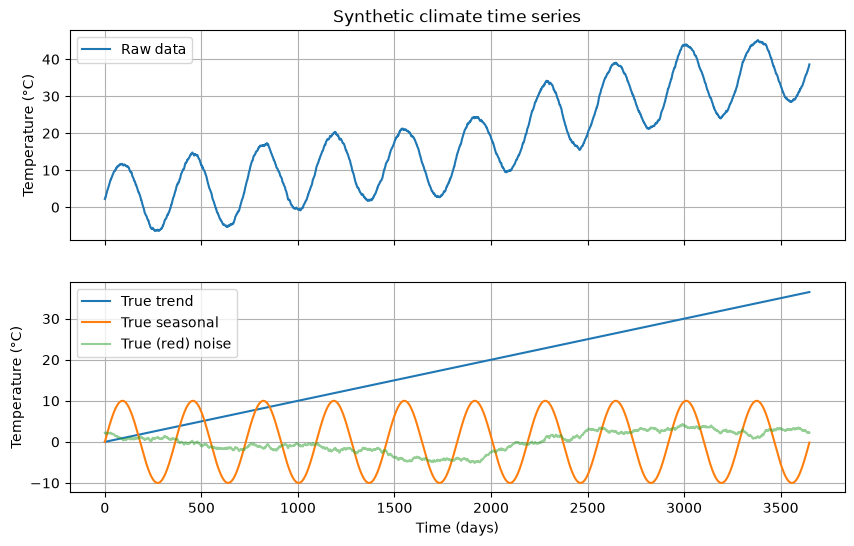

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, sosfiltfilt, sosfilt
from scipy.fft import rfft, irfft, rfftfreq

rng = np.random.default_rng(42)

# 10 years of daily data; build t from the sample count so lengths always match
fs = 1.0                     # sampling frequency: 1 sample per day
n = 365 * 10                 # number of samples
time = np.arange(n) / fs     # time in days

# true components
trend = 0.01 * time                          # long-term warming trend, deg C
seasonal = 10 * np.sin(2 * np.pi * time / 365)  # seasonal cycle, period 365 days

# red (colored) noise: shape a white spectrum by 1/f, random phases, inverse FFT
white = rng.standard_normal(n)
freqs = rfftfreq(n, d=1/fs)
shaping = np.zeros_like(freqs)
shaping[1:] = 1 / freqs[1:]      # amplitude ~ 1/f; zero out the mean
noise = irfft(rfft(white) * shaping, n=n)
noise *= 2.5 / np.std(noise)     # scale to a standard deviation of 2.5 deg C

clima = trend + seasonal + noise

# Plot the raw data and the true components
fig, ax = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
ax[0].plot(time, clima, label='Raw data')
ax[0].set_ylabel('Temperature (°C)')
ax[0].set_title('Synthetic climate time series')
ax[0].legend(); ax[0].grid(True)
ax[1].plot(time, trend, label='True trend')
ax[1].plot(time, seasonal, label='True seasonal')
ax[1].plot(time, noise, label='True (red) noise', alpha=0.5)
ax[1].set_xlabel('Time (days)'); ax[1].set_ylabel('Temperature (°C)')
ax[1].legend(); ax[1].grid(True)
plt.show()

### Retrouver chaque composante avec des filtres

Les trois composantes occupent des bandes de fréquences différentes (les fréquences sont ici en cycles par jour) :
* la tendance vit aux très basses fréquences, près de 0 ;
* le cycle saisonnier est une raie étroite à $f = 1/365 \approx 0.0027$ cycle par jour ;
* le bruit s'étale sur toutes les fréquences.

Nous concevons donc trois filtres de Butterworth :
* un **passe-bas** de coupure sous la fréquence saisonnière, pour retrouver la tendance ;
* un **passe-bande** encadrant $1/365$ cycle par jour, pour isoler le cycle saisonnier ;
* un **passe-haut** de coupure au-dessus de la fréquence saisonnière, pour isoler le bruit.

Nous utilisons ``butter(..., output='sos')``, qui renvoie le filtre en *sections du second ordre* (*second-order sections*) : un produit de polynômes du second ordre qui représente le même filtre mais est numériquement plus stable que la forme polynomiale ``(b, a)``, surtout aux ordres de filtre élevés. Nous appliquons le filtre avec ``sosfiltfilt``, qui exécute le filtre en avant puis en arrière pour un résultat sans déphasage (nous y revenons plus bas).

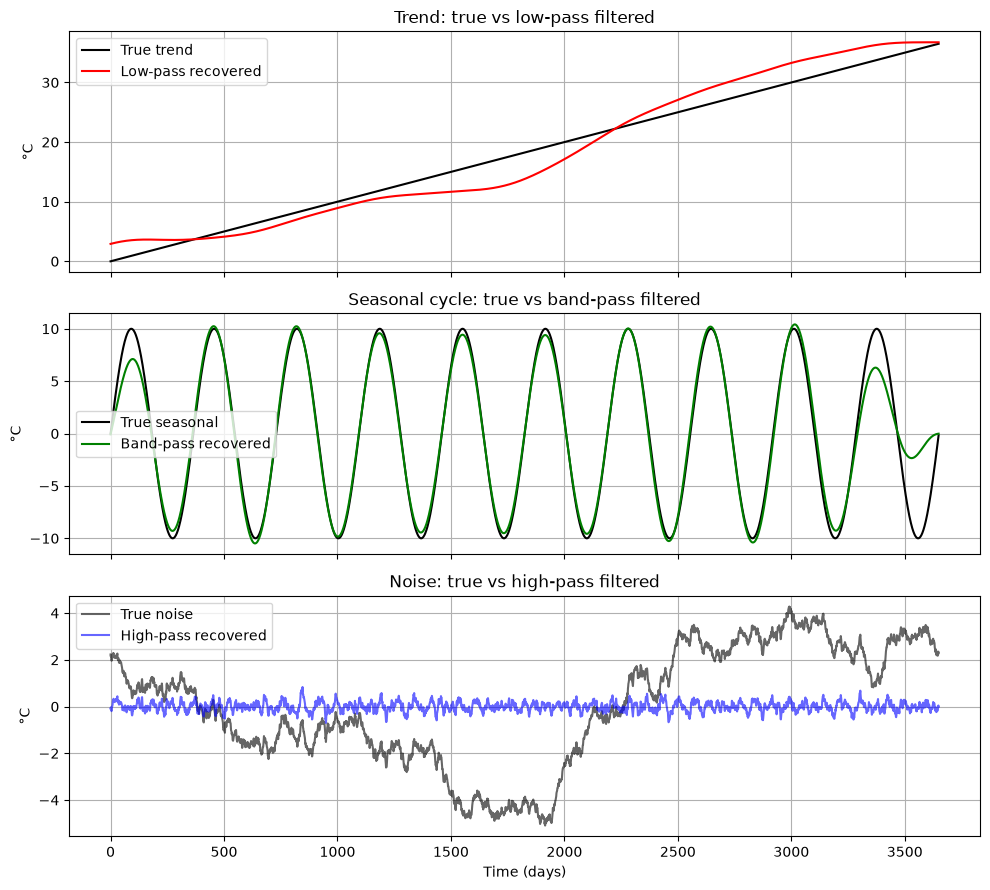

RMS error of recovered trend: 2.45 °C
RMS error of recovered seasonal: 1.55 °C
RMS error of recovered noise: 2.49 °C


In [2]:
# Low-pass to recover the trend: cutoff at 1/700 cycles/day, below the seasonal line
sos_lp = butter(4, 1/700, btype='lowpass', fs=fs, output='sos')
clima_trend = sosfiltfilt(sos_lp, clima)

# Band-pass to isolate the seasonal cycle: 1/500 to 1/250 cycles/day brackets 1/365
sos_bp = butter(2, [1/500, 1/250], btype='bandpass', fs=fs, output='sos')
clima_seasonal = sosfiltfilt(sos_bp, clima)

# High-pass to isolate the noise: cutoff at 1/100 cycles/day, above the seasonal line
sos_hp = butter(4, 1/100, btype='highpass', fs=fs, output='sos')
clima_noise = sosfiltfilt(sos_hp, clima)

fig, ax = plt.subplots(3, 1, figsize=(10, 9), sharex=True)
ax[0].plot(time, trend, 'k', label='True trend')
ax[0].plot(time, clima_trend, 'r', label='Low-pass recovered')
ax[0].set_ylabel('°C'); ax[0].set_title('Trend: true vs low-pass filtered')
ax[0].legend(); ax[0].grid(True)

ax[1].plot(time, seasonal, 'k', label='True seasonal')
ax[1].plot(time, clima_seasonal, 'g', label='Band-pass recovered')
ax[1].set_ylabel('°C'); ax[1].set_title('Seasonal cycle: true vs band-pass filtered')
ax[1].legend(); ax[1].grid(True)

ax[2].plot(time, noise, 'k', label='True noise', alpha=0.6)
ax[2].plot(time, clima_noise, 'b', label='High-pass recovered', alpha=0.6)
ax[2].set_xlabel('Time (days)'); ax[2].set_ylabel('°C')
ax[2].set_title('Noise: true vs high-pass filtered')
ax[2].legend(); ax[2].grid(True)
plt.tight_layout()
plt.show()

# quantify the recovery errors
for name, true_c, rec in [('trend', trend, clima_trend),
                          ('seasonal', seasonal, clima_seasonal),
                          ('noise', noise, clima_noise)]:
    rms = np.sqrt(np.mean((true_c - rec)**2))
    print(f"RMS error of recovered {name}: {rms:.2f} °C")

### Pourquoi la récupération est imparfaite : fuite spectrale entre composantes

La tendance retrouvée n'est pas une droite : elle vagabonde autour de la vraie tendance. Le bruit retrouvé manque une partie du vrai bruit. Ce n'est pas un bogue des filtres — c'est une propriété des données.

Un filtre sépare les signaux par *bande de fréquences*. Il ne peut séparer proprement des composantes que si elles occupent des bandes disjointes. Ici, le bruit rouge a de la puissance à toutes les fréquences, y compris sous la coupure du passe-bas. Cette partie basse fréquence du bruit traverse le filtre passe-bas avec la tendance, et le filtre n'a aucun moyen de les distinguer. La même fuite contamine la sortie du passe-bande : la série « saisonnière » retrouvée contient la puissance du bruit qui tombe dans la bande passante, donc son amplitude fluctue d'année en année alors que le vrai cycle saisonnier est parfaitement régulier. Pendant ce temps, la sortie du passe-haut manque la partie basse fréquence du bruit — et le bruit rouge tient l'essentiel de sa puissance aux basses fréquences, donc le filtre passe-haut ne retrouve qu'une petite fraction du vrai bruit et son erreur RMS est presque aussi grande que le bruit lui-même.

Notez aussi les bords du filtre : près du début et de la fin de la série, le filtre dispose de données incomplètes et la sortie est déformée. Les effets de bord sont un artefact standard du filtrage ; apodisez ou rognez les bords avant de les interpréter.

La leçon : le filtrage retrouve une *bande de fréquences*, pas une *composante physique*. Les deux ne coïncident que lorsque les composantes sont spectralement séparées. Avec du bruit coloré, une part de fuite est inévitable, et vous devez la rapporter plutôt que l'ignorer.

### Filtrage à phase nulle contre filtrage causal

``scipy.signal`` offre deux façons d'appliquer un filtre SOS :
* ``sosfilt`` exécute le filtre en avant dans le temps seulement. C'est un filtre **causal** : la sortie à l'instant $t$ ne dépend que des échantillons jusqu'à $t$. C'est la seule option dans les systèmes en temps réel, et il préserve le début d'un signal — rien n'apparaît dans la sortie avant d'apparaître dans l'entrée. Le coût est un retard de phase dépendant de la fréquence : les caractéristiques de la sortie arrivent en retard.
* ``sosfiltfilt`` exécute le filtre en avant, puis en arrière. Les deux passes annulent mutuellement leur retard de phase, donc la sortie est **à phase nulle** : les caractéristiques filtrées restent alignées en temps avec les données brutes. Le coût est que le filtre n'est plus causal — de l'énergie fuit en arrière dans le temps, si bien qu'un début abrupt acquiert un petit précurseur. Utilisez-le pour l'analyse hors ligne quand l'alignement temporel compte, jamais pour du traitement en temps réel, et méfiez-vous des pointés de temps d'arrivée près des débuts abrupts.

Nous montrons la différence sur les données sismiques ci-dessous, où le début abrupt de l'onde P rend le retard de phase facile à voir.

#### Cas d'usage en géosciences :
- **Études du changement climatique** : filtrer les données de température pour retirer le bruit et se concentrer sur les tendances de long terme.
- **Détection d'El Niño et de La Niña** : le filtrage aide à identifier les oscillations périodiques dans les données de température de surface de la mer.
- **Prévision météorologique** : les filtres passe-haut isolent les variations de court terme pour l'analyse.

## Exemple 2 : application à la sismologie

Nous téléchargeons les mêmes données que dans la leçon 2.8 : des sismogrammes enregistrés dans le Puget Sound (station UW.RATT) pour le séisme de Chignik (Alaska) de magnitude 8,2 du 29 juillet 2021, plus une fenêtre de bruit avant l'événement. Nous interrogeons le centre de données FDSN avec le client `IRIS` ; notez que les services de données IRIS sont désormais opérés par [EarthScope](https://www.earthscope.org/), mais le nom de client `IRIS` fonctionne toujours.

Le code de canal `HHZ` désigne un sismomètre large bande à gain élevé, échantillonné à 100 échantillons par seconde, composante verticale. Nous gardons ici les données en comptes bruts du numériseur (nous ne retirons pas la réponse instrumentale), donc les axes d'amplitude sont étiquetés en comptes.

In [3]:
# Import modules for seismic data
import os

import scipy.signal as signal

# seismic python toolbox
import obspy
import obspy.clients.fdsn.client as fdsn
from obspy import UTCDateTime

os.makedirs('data', exist_ok=True)

In [4]:
# Download seismic data
network = 'UW'
station = 'RATT'
channel = 'HHZ'  # broadband high-gain vertical channel, 100 samples per second
Tstart = UTCDateTime(2021, 7, 29, 6, 15)
Tend = Tstart + 7200
fdsn_client = fdsn.Client('IRIS')  # client to query the EarthScope (formerly IRIS) DMC server

# call to download the specific data: earthquake waveforms
Z = fdsn_client.get_waveforms(network=network, station=station, location='--', channel=channel,
                              starttime=Tstart, endtime=Tend)
# basic pre-processing: merge if there are gaps, detrend, taper
Z.merge(); Z.detrend(type='linear'); Z[0].taper(max_percentage=0.05)

# call to download the specific data: noise waveforms (the two hours before the earthquake)
N = fdsn_client.get_waveforms(network=network, station=station, location='--', channel=channel,
                              starttime=Tstart - 7200, endtime=Tstart)
N.merge(); N.detrend(type='linear'); N[0].taper(max_percentage=0.05)

/Users/marinedenolle/Dropbox/CLASSES/ESS490/curriculum-book/.pixi/envs/default/lib/python3.12/site-packages/obspy/clients/fdsn/client.py:251: ObsPyDeprecationWarning: IRIS is now EarthScope, please consider changing the FDSN client short URL to 'EARTHSCOPE'.
  warnings.warn(msg, ObsPyDeprecationWarning)


UW.RATT..HHZ | 2021-07-29T04:15:00.000000Z - 2021-07-29T06:14:59.990000Z | 100.0 Hz, 720000 samples

Text(0.5, 0, 'Sample index')

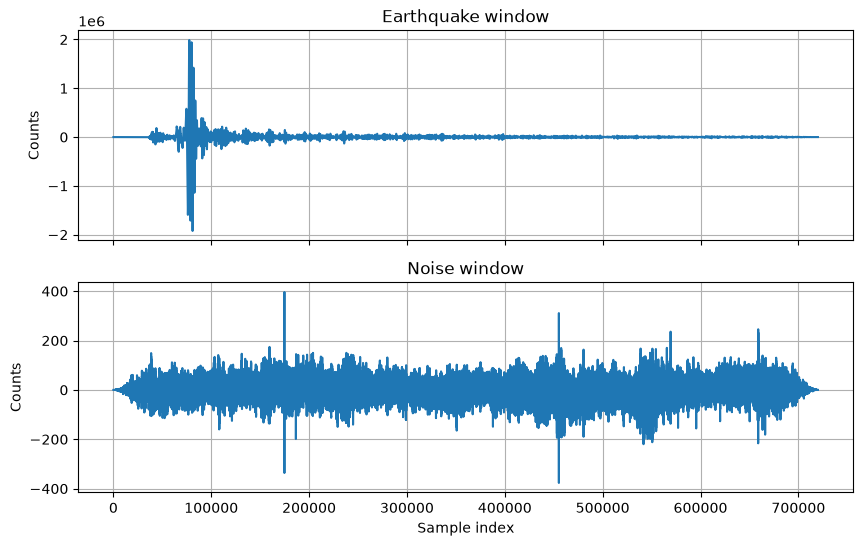

In [5]:
fig, ax = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
ax[0].plot(Z[0].data); ax[0].grid(True); ax[0].set_ylabel('Counts'); ax[0].set_title('Earthquake window')
ax[1].plot(N[0].data); ax[1].grid(True); ax[1].set_ylabel('Counts'); ax[1].set_title('Noise window')
ax[1].set_xlabel('Sample index')

Nous utiliserons le module ``scipy.signal`` pour filtrer la série temporelle.

In [6]:
# sampling rate of the data:
fs = Z[0].stats.sampling_rate
z = np.asarray(Z[0].data)
n_ = np.asarray(N[0].data)

# build the time vector from the number of samples so lengths always match
t = np.arange(len(z)) / fs

Nous utilisons un filtre de [*Butterworth*](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.butter.html) du second ordre, passe-bande entre les fréquences de 1 Hz et 10 Hz. La sortie ``sos`` est une représentation en *sections du second ordre* : le filtre s'exprime comme un produit de polynômes du second ordre, ce qui est numériquement plus stable que la forme en un seul polynôme d'ordre élevé. Nous appliquons le filtre avec ``sosfiltfilt`` pour un résultat à phase nulle.

In [7]:
sos = signal.butter(2, [1, 10], 'bandpass', fs=fs, output='sos')
zf = signal.sosfiltfilt(sos, z)
nf = signal.sosfiltfilt(sos, n_)

Text(0.5, 0, 'Time in seconds')

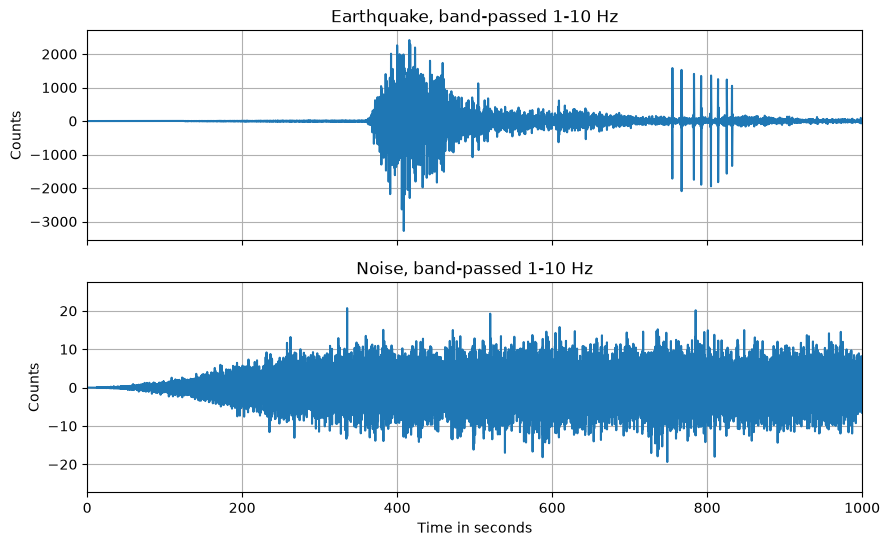

In [8]:
fig, axis = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
axis[0].plot(t, zf); axis[0].set_ylabel('Counts'); axis[0].set_title('Earthquake, band-passed 1-10 Hz')
axis[1].plot(t[:len(nf)], nf); axis[1].set_ylabel('Counts'); axis[1].set_title('Noise, band-passed 1-10 Hz')
axis[0].set_xlim([0, 1000]); axis[1].set_xlim([0, 1000])
axis[0].grid(True); axis[1].grid(True)
axis[1].set_xlabel('Time in seconds')

Filtrez maintenant dans une bande de fréquences plus haute (10–40 Hz) et comparez les signaux du séisme et du bruit.

(700.0, 1000.0)

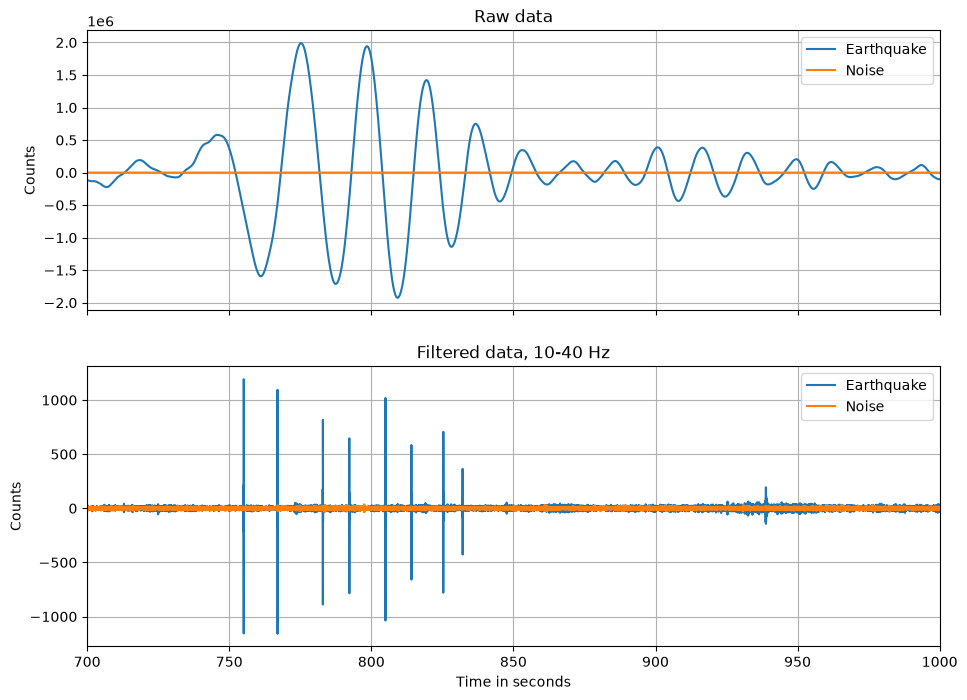

In [9]:
sos_hf = signal.butter(2, [10, 40.], 'bandpass', fs=fs, output='sos')
zf_hf = signal.sosfiltfilt(sos_hf, z)
nf_hf = signal.sosfiltfilt(sos_hf, n_)

fig, ax = plt.subplots(2, 1, figsize=(11, 8), sharex=True)
ax[0].plot(t, z); ax[0].plot(t[:len(n_)], n_); ax[0].grid(True)
ax[0].set_title('Raw data'); ax[0].legend(['Earthquake', 'Noise']); ax[0].set_ylabel('Counts')
ax[1].plot(t, zf_hf); ax[1].plot(t[:len(nf_hf)], nf_hf); ax[1].grid(True)
ax[1].set_title('Filtered data, 10-40 Hz'); ax[1].legend(['Earthquake', 'Noise']); ax[1].set_ylabel('Counts')
ax[1].set_xlabel('Time in seconds')
ax[0].set_xlim([700, 1000])
ax[1].set_xlim([700, 1000])

Le séisme se détache du bruit dans les deux bandes de fréquences. Dans la bande 10–40 Hz, l'onde P est l'arrivée dominante : les hautes fréquences s'atténuent avec la distance, donc les phases plus tardives et plus lentes sont appauvries en énergie haute fréquence.

### Filtrage à phase nulle (`sosfiltfilt`) contre filtrage causal (`sosfilt`)

Nous appliquons maintenant le même filtre passe-bande 1–10 Hz des deux façons et zoomons sur le début de l'onde P.

Text(0.5, 1.0, 'Zoom on the P-wave onset')

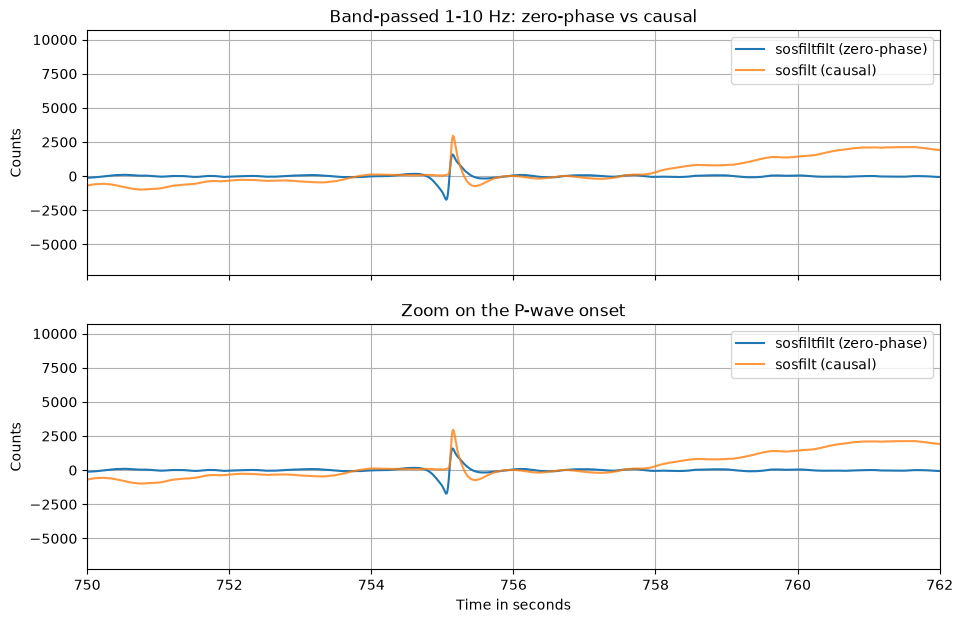

In [10]:
zf_zerophase = signal.sosfiltfilt(sos, z)  # forward-backward: zero phase
zf_causal = signal.sosfilt(sos, z)         # forward only: causal, phase-delayed

fig, ax = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
ax[0].plot(t, zf_zerophase, label='sosfiltfilt (zero-phase)')
ax[0].plot(t, zf_causal, label='sosfilt (causal)', alpha=0.8)
ax[0].set_xlim([700, 1000]); ax[0].grid(True); ax[0].legend()
ax[0].set_ylabel('Counts'); ax[0].set_title('Band-passed 1-10 Hz: zero-phase vs causal')

ax[1].plot(t, zf_zerophase, label='sosfiltfilt (zero-phase)')
ax[1].plot(t, zf_causal, label='sosfilt (causal)', alpha=0.8)
ax[1].set_xlim([750, 762]); ax[1].grid(True); ax[1].legend()
ax[1].set_ylabel('Counts'); ax[1].set_xlabel('Time in seconds')
ax[1].set_title('Zoom on the P-wave onset')

Dans le panneau zoomé, la sortie causale ``sosfilt`` est décalée plus tard dans le temps par rapport à la sortie à phase nulle ``sosfiltfilt`` : le retard de phase du filtre déplace le début apparent. La version à phase nulle reste alignée avec les données brutes, mais elle y parvient en filtrant en arrière dans le temps, ce qui étale une petite quantité d'énergie *avant* le début.

Conseils pratiques :
* Utilisez le **filtrage causal** (``sosfilt``) pour les applications en temps réel (alerte sismique précoce) et quand la présence ou l'absence d'énergie avant un début compte. Si vous pointez des temps d'arrivée sur des données filtrées causalement, corrigez le retard du filtre ou acceptez un biais.
* Utilisez le **filtrage à phase nulle** (``sosfiltfilt``) pour l'analyse hors ligne où l'alignement temporel entre données brutes et filtrées compte. N'interprétez pas les petites ondulations précurseuses près des débuts abrupts : ce peuvent être des artefacts de filtre.

## Exemple 3 : filtrer des enregistrements imparfaits — une lacune et une erreur d'horloge

Tout ce qui précède supposait un enregistrement continu et correctement daté. Les vraies archives ne sont pas si obligeantes : la télémétrie décroche, les disques se remplissent, les horloges GPS perdent leur verrouillage. L'enregistrement RATT se trouve être complet et bien daté — alors nous en cassons une copie, exprès. Ainsi, l'enregistrement intact est la vérité terrain, et chaque réparation est notée.

### Une lacune dans l'enregistrement

Nous supprimons 20 secondes de la coda et les remplaçons par des zéros, ce qui est la façon dont beaucoup d'archives (et un `merge` négligent) livrent les interruptions. Puis nous filtrons tout droit à travers, comme si de rien n'était.

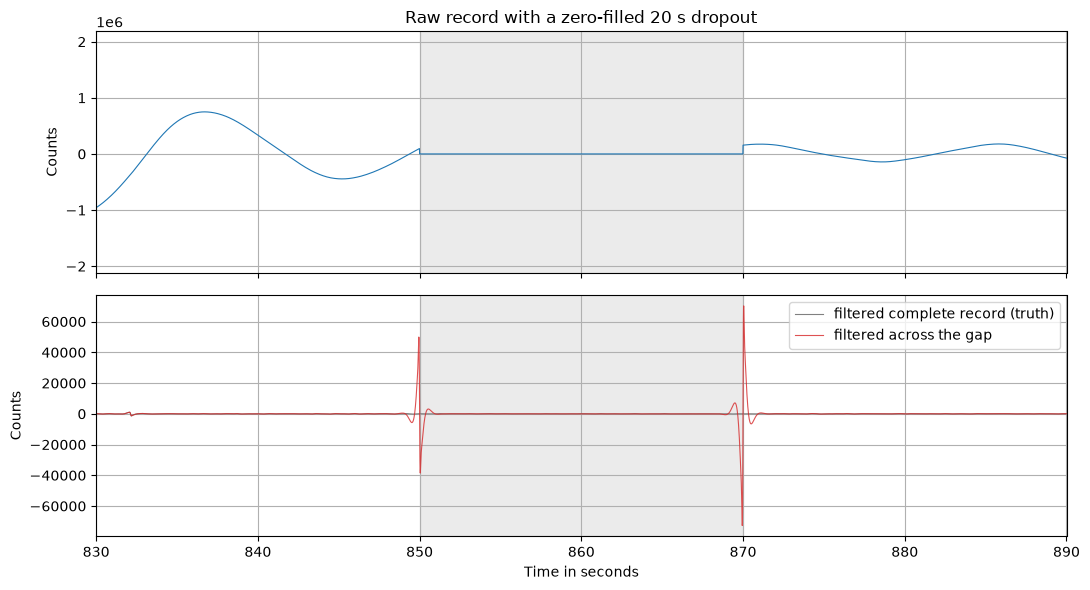

distance from gap   local signal RMS   naive filtering error
  0-2 s                70 counts        12998 counts ( 185.13x the signal)
  2-5 s                74 counts            1 counts (   0.02x the signal)
  5-10 s                62 counts            0 counts (   0.00x the signal)


In [11]:
# Inject a 20 s dropout into the coda, zero-filled
gap_start, gap_end = 850.0, 870.0
i0, i1 = int(gap_start * fs), int(gap_end * fs)
z_gap = z.astype(float).copy()
z_gap[i0:i1] = 0.0

zf_gap = signal.sosfiltfilt(sos, z_gap)  # naive: filter straight across the gap

fig, ax = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
ax[0].plot(t, z_gap, lw=0.8)
ax[0].set_ylabel('Counts'); ax[0].set_title('Raw record with a zero-filled 20 s dropout')
ax[1].plot(t, zf, color='gray', lw=0.8, label='filtered complete record (truth)')
ax[1].plot(t, zf_gap, color='tab:red', lw=0.8, alpha=0.8, label='filtered across the gap')
ax[1].set_ylabel('Counts'); ax[1].set_xlabel('Time in seconds'); ax[1].legend()
for a in ax:
    a.axvspan(gap_start, gap_end, color='k', alpha=0.08)
    a.set_xlim([830, 890]); a.grid(True)
plt.tight_layout()
plt.show()

# Grade against the complete-record reference, by distance from the gap edges
print('distance from gap   local signal RMS   naive filtering error')
for lo, hi in [(0, 2), (2, 5), (5, 10)]:
    w = (((t >= gap_start - hi) & (t < gap_start - lo))
         | ((t >= gap_end + lo) & (t < gap_end + hi)))
    srms = np.sqrt(np.mean(zf[w] ** 2))
    err = np.sqrt(np.mean((zf_gap[w] - zf[w]) ** 2))
    print(f'  {lo}-{hi} s           {srms:7.0f} counts     {err:8.0f} counts '
          f'({err / srms:7.2f}x the signal)')

Le dégât est sans commune mesure avec la lacune. Le remplissage par des zéros crée deux discontinuités en marche d'escalier dont la hauteur est l'amplitude *brute* — dominée ici par les ondes de surface longue période, des dizaines de milliers de comptes — alors que le vrai signal 1–10 Hz dans cette partie de la coda est sous la centaine de comptes. Une marche est large bande, donc le filtre répond par sa propre oscillation aux fréquences de coupure : à moins de deux secondes de chaque bord, la sortie dépasse cent fois le signal, et à l'intérieur de la lacune la sortie naïve montre des oscillations d'allure plausible qui sont un pur artefact de filtre. Comme dans la leçon 2.6, les échantillons fabriqués sont les plus dangereux — ils ressemblent à des données.

Aucun filtre ne peut ressusciter les 20 secondes qui n'ont jamais été enregistrées ; réparer, c'est *confiner le dégât*. La correction est le **filtrage par segments** : filtrer séparément chaque segment contigu de données réelles et laisser la lacune en `NaN`. ``sosfiltfilt`` complète chaque segment en interne (réflexion impaire autour des extrémités), donc aucun segment ne voit jamais de marche.

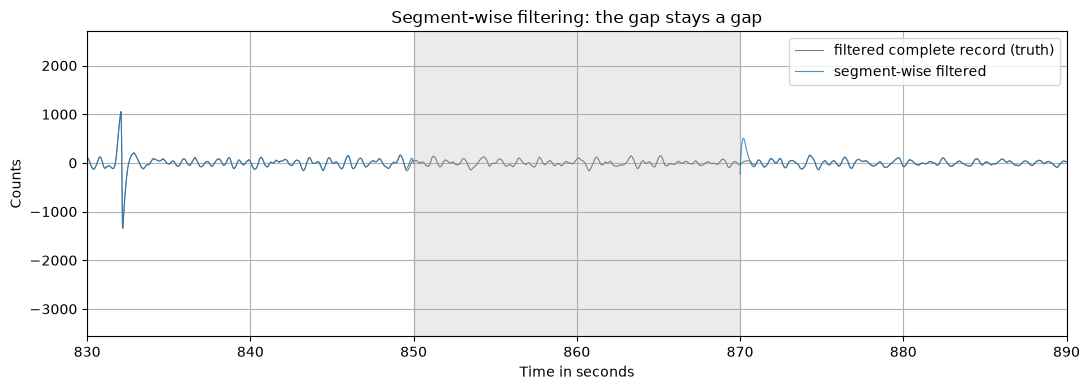

distance from gap   naive error         segment-wise error
  0-2 s            185.13x signal      1.7491x signal
  2-5 s              0.02x signal      0.0005x signal
  5-10 s              0.00x signal      0.0000x signal


In [12]:
def filter_with_gaps(x, bad, sos):
    """Zero-phase filter each contiguous valid segment separately.

    The gap itself stays NaN: declared missing, not repaired."""
    out = np.full(len(x), np.nan)
    good_idx = np.flatnonzero(~bad)
    segments = np.split(good_idx, np.flatnonzero(np.diff(good_idx) > 1) + 1)
    for seg in segments:
        out[seg] = signal.sosfiltfilt(sos, x[seg].astype(float))
    return out

bad = np.zeros(len(z), dtype=bool)
bad[i0:i1] = True
zf_seg = filter_with_gaps(z, bad, sos)

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(t, zf, color='gray', lw=0.8, label='filtered complete record (truth)')
ax.plot(t, zf_seg, color='tab:blue', lw=0.8, alpha=0.8, label='segment-wise filtered')
ax.axvspan(gap_start, gap_end, color='k', alpha=0.08)
ax.set_xlim([830, 890]); ax.grid(True); ax.legend()
ax.set_xlabel('Time in seconds'); ax.set_ylabel('Counts')
ax.set_title('Segment-wise filtering: the gap stays a gap')
plt.tight_layout()
plt.show()

print('distance from gap   naive error         segment-wise error')
for lo, hi in [(0, 2), (2, 5), (5, 10)]:
    w = (((t >= gap_start - hi) & (t < gap_start - lo))
         | ((t >= gap_end + lo) & (t < gap_end + hi)))
    srms = np.sqrt(np.mean(zf[w] ** 2))
    en = np.sqrt(np.mean((zf_gap[w] - zf[w]) ** 2))
    es = np.sqrt(np.nanmean((zf_seg[w] - zf[w]) ** 2))
    print(f'  {lo}-{hi} s          {en / srms:8.2f}x signal    {es / srms:8.4f}x signal')

Noté contre l'enregistrement complet : le filtrage par segments réduit l'erreur près des bords de deux ordres de grandeur, et au-delà de deux secondes de la lacune il égale la vérité à mieux qu'une fraction de pour cent. La contamination résiduelle s'étend sur environ deux secondes — quelques périodes de la plus basse fréquence de la bande passante (1 Hz), qui est la mémoire du filtre. La recette pratique : filtrer par segments, garder les lacunes comme manquantes et signaler dans vos métadonnées un intervalle de garde de quelques périodes de filtre à chaque bord de segment, pour que les utilisateurs en aval (ou votre propre code d'extraction de caractéristiques en 2.11) sachent quels échantillons croire.

### Une erreur d'horloge

La seconde pathologie laisse la forme d'onde parfaite et ne corrompt que les horodatages. La dérive des horloges GPS, les bogues de seconde intercalaire et les redémarrages de numériseur produisent couramment des erreurs de datation inférieures à la seconde — invisibles à l'œil sur n'importe quel graphique, et fatales pour les pointés de phase, la tomographie par corrélation croisée et toute étiquette de ML dérivée de temps d'arrivée. Nous simulons un instrument dont l'horloge retarde d'une demi-seconde, et retrouvons le décalage de la façon standard : **corréler avec une référence** et lire le décalage temporel du pic.

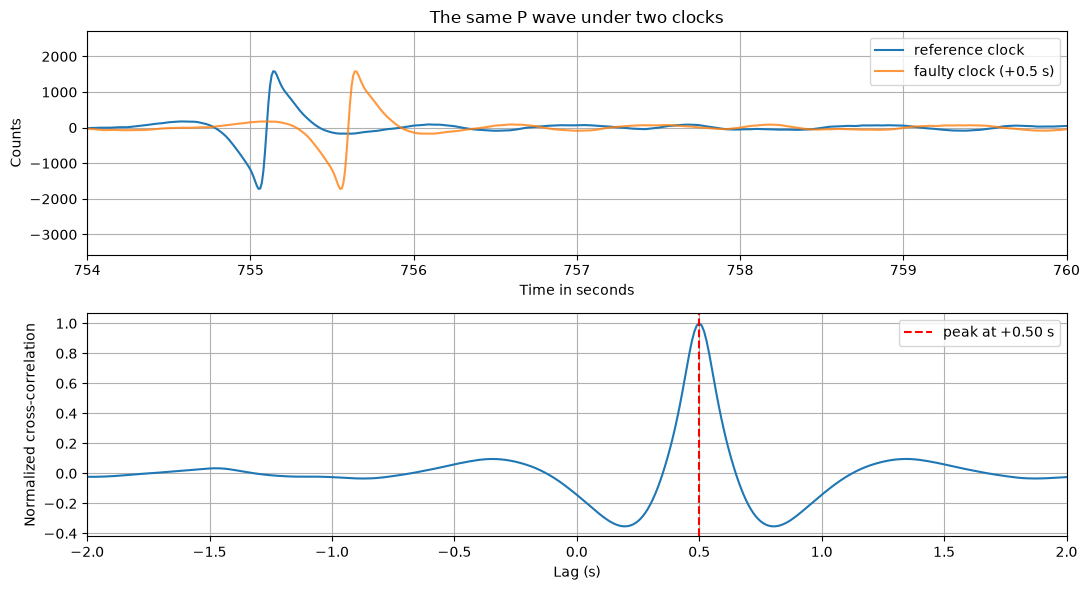

injected clock offset:  +0.50 s
recovered from the cross-correlation peak: +0.50 s


In [13]:
offset_true = 0.5  # seconds = 50 samples at 100 Hz
z_late = np.roll(z, int(offset_true * fs))  # same ground motion, stamped 0.5 s late
zf_late = signal.sosfiltfilt(sos, z_late.astype(float))

# Cross-correlate a 60 s window spanning the P arrival
w0, w1 = int(740 * fs), int(800 * fs)
a, b = zf[w0:w1], zf_late[w0:w1]
cc = signal.correlate(b, a, mode='full')
lags = signal.correlation_lags(len(b), len(a), mode='full') / fs
lag_best = lags[np.argmax(cc)]

fig, ax = plt.subplots(2, 1, figsize=(11, 6))
ax[0].plot(t, zf, label='reference clock')
ax[0].plot(t, zf_late, label='faulty clock (+0.5 s)', alpha=0.8)
ax[0].set_xlim([754, 760]); ax[0].grid(True); ax[0].legend()
ax[0].set_ylabel('Counts'); ax[0].set_xlabel('Time in seconds')
ax[0].set_title('The same P wave under two clocks')
ax[1].plot(lags, cc / cc.max())
ax[1].axvline(lag_best, color='r', ls='--', label=f'peak at {lag_best:+.2f} s')
ax[1].set_xlim([-2, 2]); ax[1].grid(True); ax[1].legend()
ax[1].set_xlabel('Lag (s)'); ax[1].set_ylabel('Normalized cross-correlation')
plt.tight_layout()
plt.show()

print(f'injected clock offset:  {offset_true:+.2f} s')
print(f'recovered from the cross-correlation peak: {lag_best:+.2f} s')

Le pic de corrélation croisée se trouve exactement au décalage injecté : des erreurs de datation qu'aucune inspection visuelle ne détecterait sont récupérables à l'échantillon près, et à une fraction d'échantillon près si vous interpolez le pic de corrélation (ajustez une parabole aux trois points autour du maximum). Sur données réelles, la référence est un capteur co-localisé, une station voisine corrigée de la différence de temps de trajet prédite, ou — pour les méthodes de bruit ambiant — la moyenne de long terme de la corrélation de bruit elle-même, ce qui est la façon dont les réseaux modernes surveillent en continu la dérive des horloges. La version à cadence journalière de cette pathologie (une série GNSS rapportant le champ au mauvais jour) est l'un des défauts injectables de `mlgeo_synth.degrade_series`, et la logique de réparation est la même : détecter par corrélation avec une référence, puis décaler.

#### Conclusion
Filtrer des séries temporelles est une étape de routine de l'analyse géoscientifique. Le filtrage isole des bandes de fréquences, retire du bruit et révèle des tendances — mais il sépare des *bandes*, pas des composantes physiques, et chaque choix de filtre (fréquences de coupure, ordre, causal ou à phase nulle) laisse une signature dans la sortie. Connaissez cette signature avant d'interpréter le résultat. Et avant même de filtrer, vérifiez l'enregistrement lui-même : filtrez à travers une lacune remplie de zéros et l'artefact pèsera plus lourd que le signal ; croyez un horodatage sans référence et une erreur d'une demi-seconde s'insinuera silencieusement dans chaque produit en aval.